In [9]:
import joblib
import shap
import xgboost as xgb

# Cargar modelo entrenado
model = joblib.load("model.joblib")

# Cargar datasets
X_train = joblib.load("train_dataset.joblib")
X_test = joblib.load("test_dataset.joblib")


In [16]:

# Crear el explainer para XGBoost
xgb_model = model.named_steps['regressor']  # Cambia 'xgb' por el nombre real del paso en tu pipeline
explainer = shap.TreeExplainer(xgb_model)


In [23]:
# Si X_test es una tupla, extrae el DataFrame
if isinstance(X_test, tuple):
    X_test = X_test[0]
print('Columnas de X_test:', X_test.columns)

Columnas de X_test: Index(['Edad', 'IMC', 'Htopre', 'Leucograma', 'Creatininapre',
       'Proteinasatotales', 'PCR', 'TestFuerzaAgarre', 'Test5metros',
       'Estanciahospitalariacalculada', 'Género', 'DMdicotomica',
       'TabaquismoDicot', 'HTA', 'DL', 'Obesidad', 'EPOCdicot',
       'Insuficienciarenalpreoperatoria', 'ComplicacionesTODAS',
       'ComplicacionesMACE', 'FragilidadGrST', 'FragilidadGST', 'Barthel',
       'Katz', 'Frail', 'Edmonton'],
      dtype='object')


In [24]:
# Comparar y alinear columnas de X_test con las del preprocesador
import numpy as np

# Obtener las columnas esperadas por el preprocesador
expected_cols = model.named_steps['preprocessor'].feature_names_in_
print('Columnas esperadas por el preprocesador:', expected_cols)
print('Columnas de X_test:', X_test.columns)

# Si faltan columnas en X_test, las agregamos con NaN
for col in expected_cols:
    if col not in X_test.columns:
        X_test[col] = np.nan

# Reordenar las columnas de X_test para que coincidan con el preprocesador
X_test = X_test[expected_cols]
print('Columnas finales de X_test:', X_test.columns)

# Ahora puedes transformar sin error:
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

Columnas esperadas por el preprocesador: ['Htopre' 'Creatininapre' 'Estanciahospitalariacalculada'
 'ComplicacionesTODAS' 'ComplicacionesMACE' 'Edmonton']
Columnas de X_test: Index(['Edad', 'IMC', 'Htopre', 'Leucograma', 'Creatininapre',
       'Proteinasatotales', 'PCR', 'TestFuerzaAgarre', 'Test5metros',
       'Estanciahospitalariacalculada', 'Género', 'DMdicotomica',
       'TabaquismoDicot', 'HTA', 'DL', 'Obesidad', 'EPOCdicot',
       'Insuficienciarenalpreoperatoria', 'ComplicacionesTODAS',
       'ComplicacionesMACE', 'FragilidadGrST', 'FragilidadGST', 'Barthel',
       'Katz', 'Frail', 'Edmonton'],
      dtype='object')
Columnas finales de X_test: Index(['Htopre', 'Creatininapre', 'Estanciahospitalariacalculada',
       'ComplicacionesTODAS', 'ComplicacionesMACE', 'Edmonton'],
      dtype='object')


In [27]:
# Calcular valores shap
shap_values = explainer.shap_values(X_test_transformed)

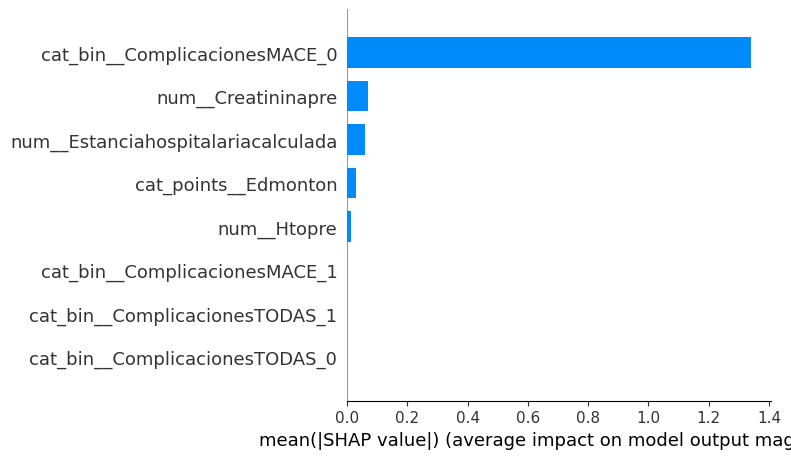

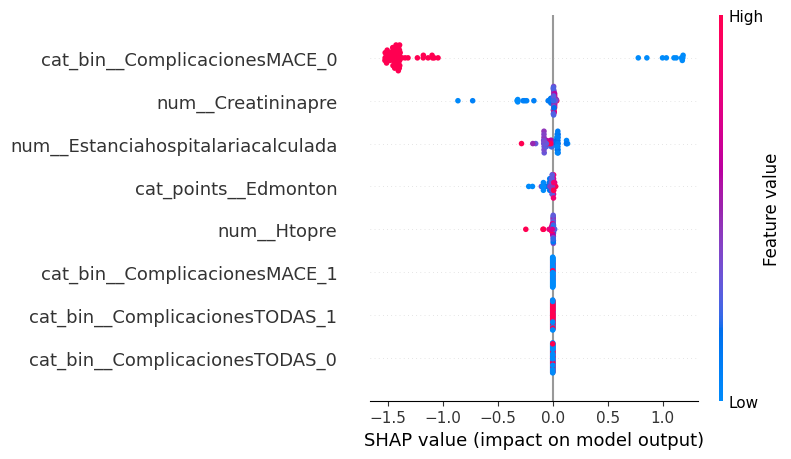

In [38]:
# Obtener nombres de las variables transformadas
if hasattr(model.named_steps['preprocessor'], 'get_feature_names_out'):
    feature_names_transformed = model.named_steps['preprocessor'].get_feature_names_out()
else:
    feature_names_transformed = [f'Feature {i}' for i in range(X_test_transformed.shape[1])]

# Usar estos nombres en summary_plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_transformed, plot_type="bar")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_transformed)

In [37]:
# Ejemplo con la primera fila del test set transformado
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_transformed[0],
    feature_names=expected_cols
)
#shap.initjs()

In [66]:
def plot_summary_custom_groups(shap_values, X_transformed, feature_names):
    import numpy as np
    # Índices de complicaciones y MACE según tus nombres
    complicaciones_indices = [i for i, name in enumerate(feature_names) if 'ComplicacionesTODAS' in name]
    mace_indices = [i for i, name in enumerate(feature_names) if 'ComplicacionesMACE' in name]
    # Agrupar complicaciones
    complicaciones_sum = np.sum(X_transformed[:, complicaciones_indices], axis=1).reshape(-1, 1)
    shap_complicaciones_sum = np.sum(shap_values[:, complicaciones_indices], axis=1).reshape(-1, 1)
    # Agrupar MACE
    mace_sum = np.sum(X_transformed[:, mace_indices], axis=1).reshape(-1, 1)
    shap_mace_sum = np.sum(shap_values[:, mace_indices], axis=1).reshape(-1, 1)
    # Eliminar columnas originales
    mask = np.ones(X_transformed.shape[1], dtype=bool)
    for idx in complicaciones_indices + mace_indices:
        mask[idx] = False
    X_new = X_transformed[:, mask]
    shap_new = shap_values[:, mask]
    feature_names_new = [feature_names[i] for i in range(len(feature_names)) if mask[i]]
    # Añadir columnas agrupadas
    X_new = np.hstack([X_new, complicaciones_sum, mace_sum])
    shap_new = np.hstack([shap_new, shap_complicaciones_sum, shap_mace_sum])
    feature_names_new += ['ComplicacionesTODAS_sum', 'ComplicacionesMACE_sum']
    # Graficar
    import shap
    feature_names_new = ['Hematocrit', 'Creatinine', 'Stay Length', 'Edmonton', 'Complications', 'MACE']
    shap.summary_plot(shap_new, X_new, feature_names=feature_names_new, plot_type="bar")
    shap.summary_plot(shap_new, X_new, feature_names=feature_names_new)


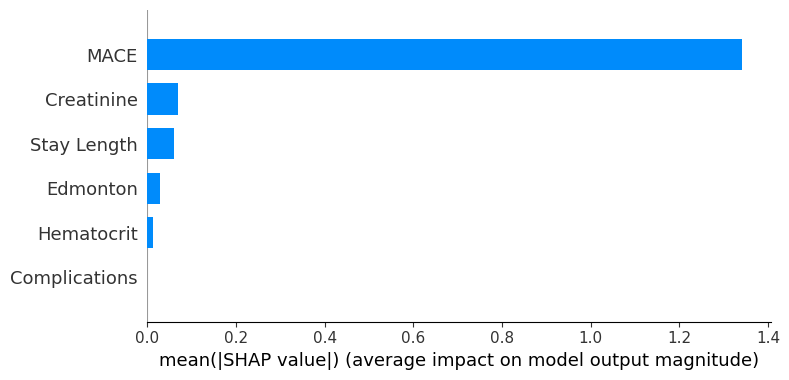

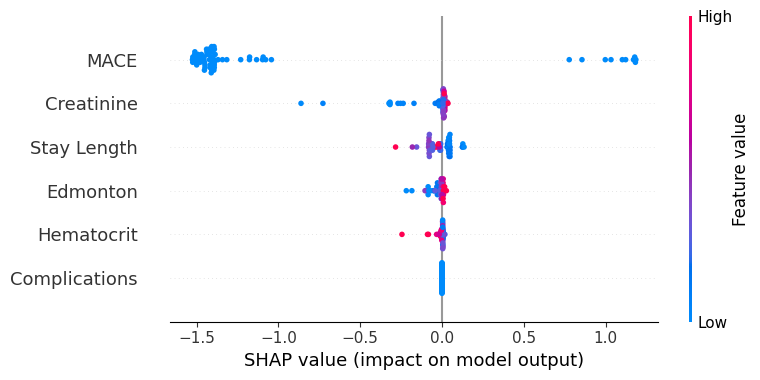

In [67]:
plot_summary_custom_groups(shap_values, X_test_transformed, feature_names_transformed)


['Hematocrit', 'Creatinine', 'Stay Length', 'Edmonton', 'Complications', 'MACE']


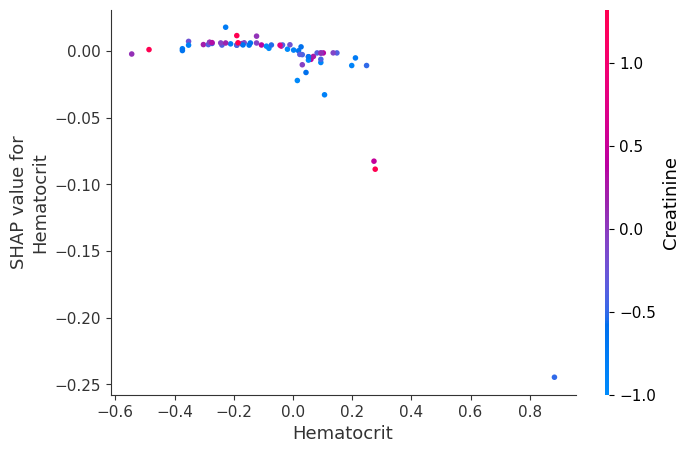

In [81]:
feature_names_new = ['Hematocrit', 'Creatinine', 'Stay Length', 'Edmonton', 'Complications', 'MACE']

print(feature_names_new)
#create dependance_plot
shap.dependence_plot(
    "Hematocrit",
    shap_values,
    X_test_transformed,
    feature_names= feature_names_new,
    interaction_index="Creatinine"
)

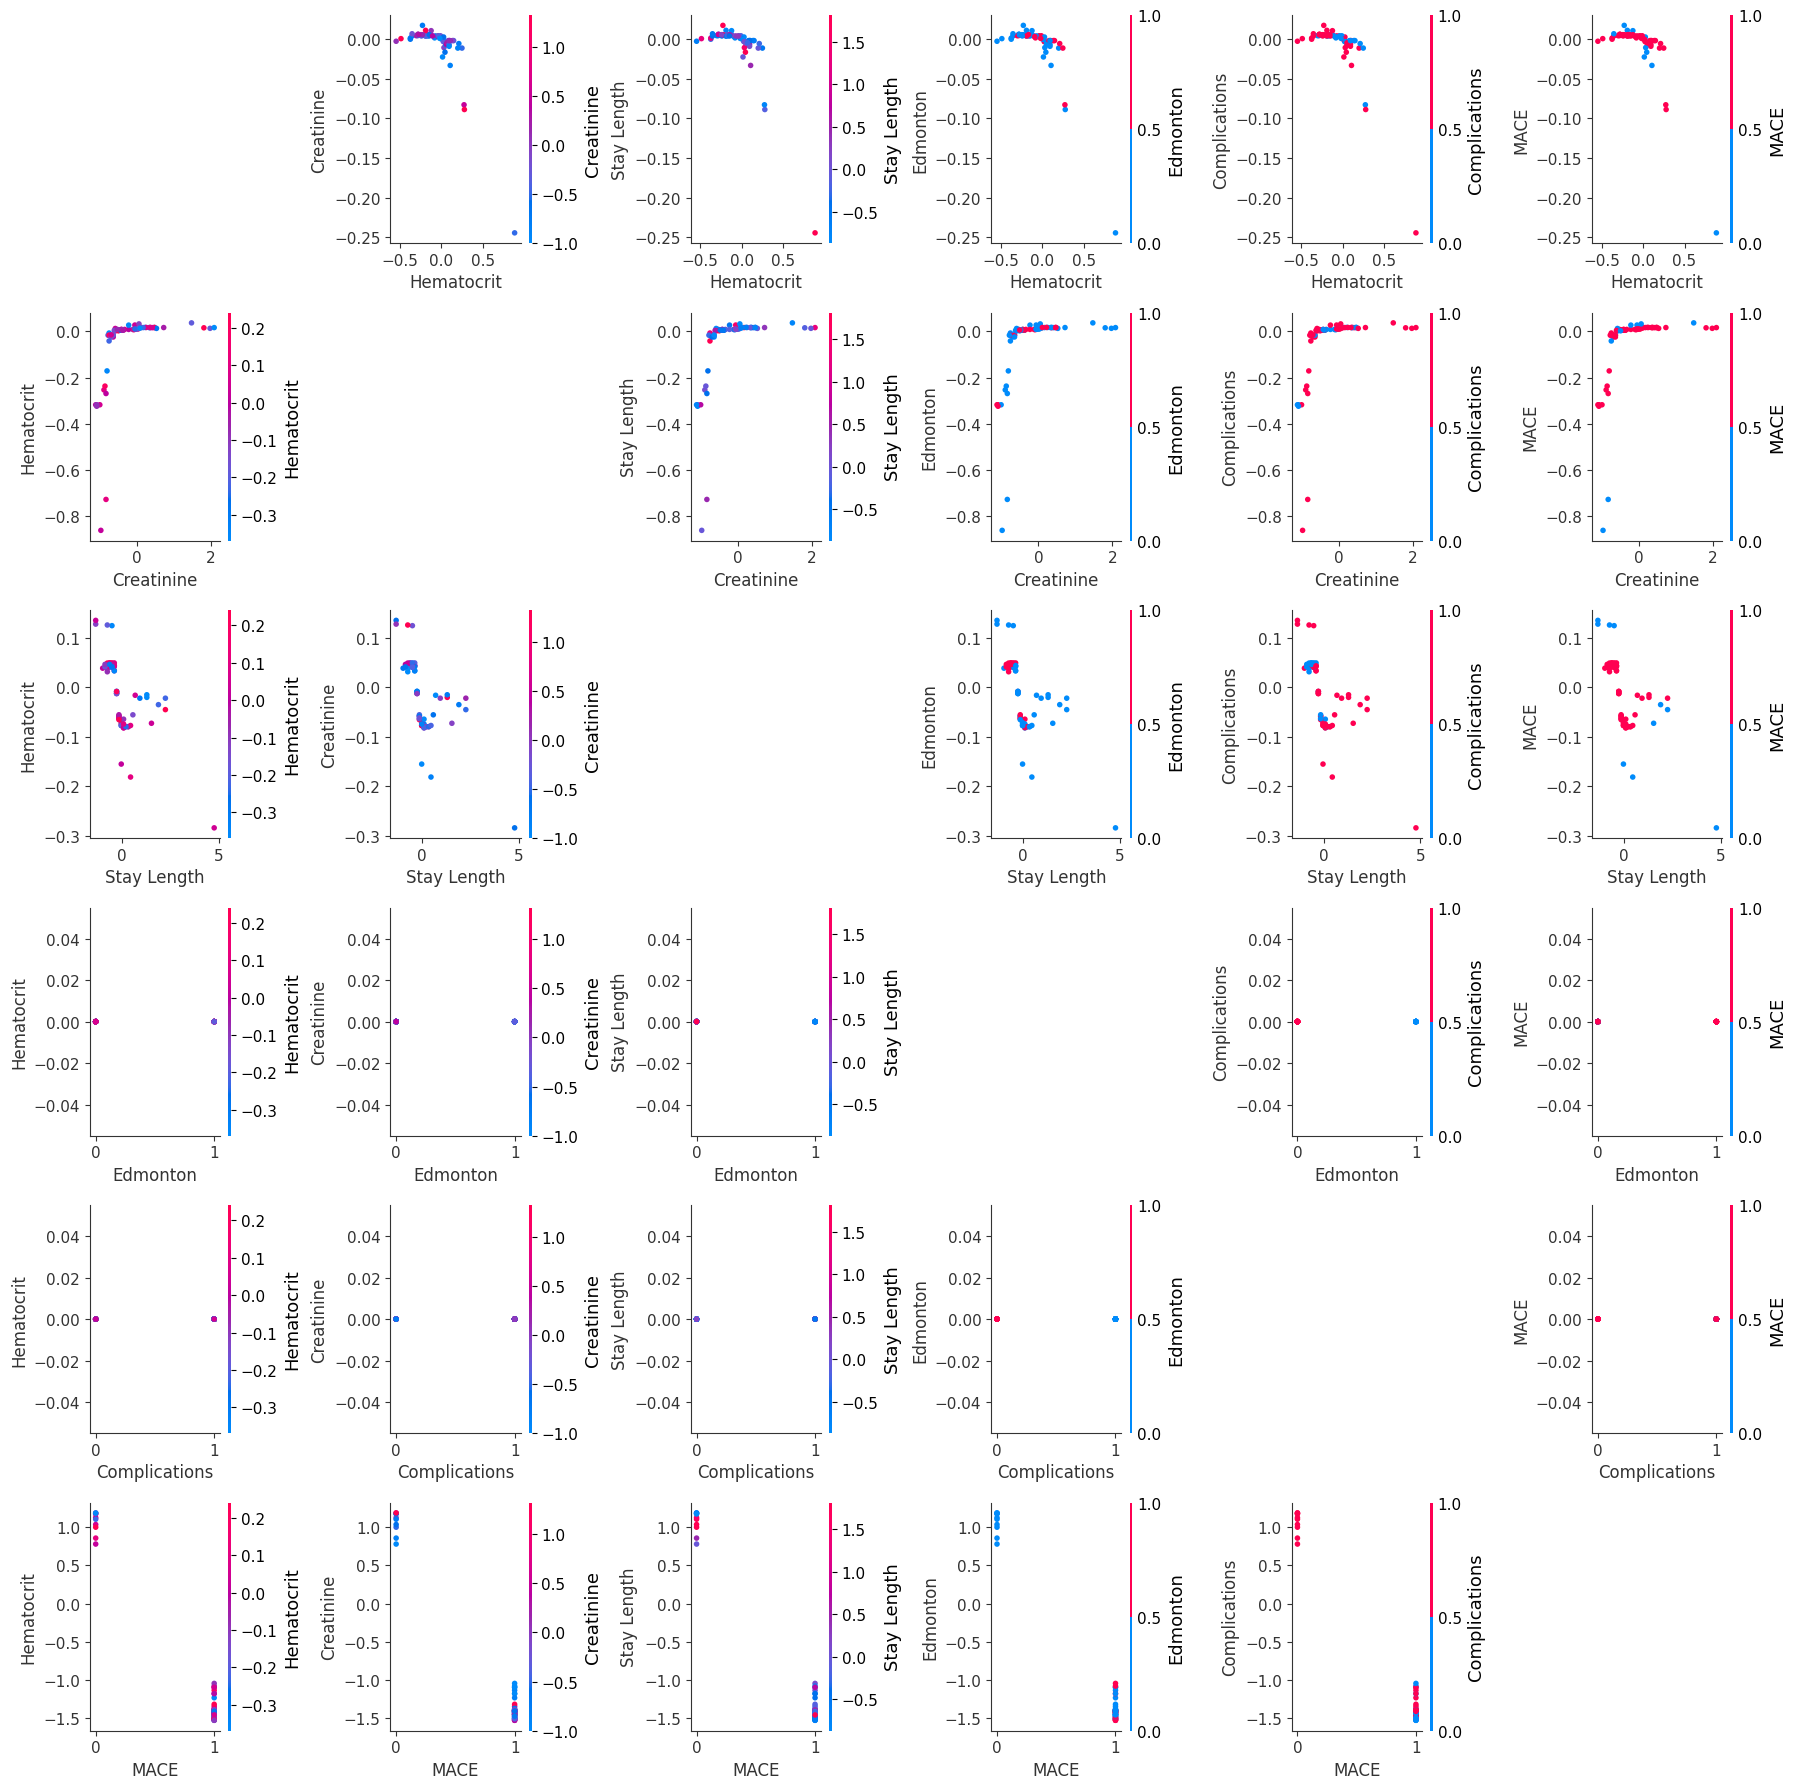

In [87]:
import matplotlib.pyplot as plt
import shap
import itertools

def shap_dependence_matrix(shap_values, X, feature_names):
    n = len(feature_names)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    
    for i, feature_x in enumerate(feature_names):
        for j, feature_y in enumerate(feature_names):
            ax = axes[i, j]
            
            # Quitar la diagonal y la mitad inferior para evitar duplicados
            if i == j:
                ax.axis("off")  # diagonal vacía
                continue
            
            # Dependence plot con interaction_index fijo
            shap.dependence_plot(
                feature_x,
                shap_values,
                X,
                feature_names=feature_names,
                interaction_index=feature_y,
                ax=ax,
                show=False
            )
            
            if i == n-1:
                ax.set_xlabel(feature_x, fontsize=12)
            else:
                ax.set_xlabel(feature_x, fontsize=12)
            if j == 0:
                ax.set_ylabel(feature_y, fontsize=12)
            else:
                ax.set_ylabel(feature_y, fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Uso
shap_dependence_matrix(shap_values, X_test_transformed, feature_names_new)


In [89]:
import numpy as np
import pandas as pd

# Obtener valores de interacción
shap_interaction_values = explainer.shap_interaction_values(X_test_transformed)

# Si hay varias clases (clasificación), seleccionar la clase que te interese
# shap_interaction_values = shap_interaction_values[0]  # Por ejemplo, clase 0

# Calcular magnitud media absoluta por par de variables
n = len(feature_names_new)
interaction_strength = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        interaction_strength[i, j] = np.abs(shap_interaction_values[:, i, j]).mean()

# Crear DataFrame para ranking
df_interactions = pd.DataFrame(interaction_strength, 
                               index=feature_names_new, 
                               columns=feature_names_new)

# Quitar diagonal (interacción de variable consigo misma)
np.fill_diagonal(interaction_strength, np.nan)

# Pasar a formato largo y ordenar
df_long = df_interactions.stack().reset_index()
df_long.columns = ["Feature 1", "Feature 2", "Mean |SHAP interaction|"]
df_long = df_long.dropna().sort_values(by="Mean |SHAP interaction|", ascending=False)

# Mostrar top 10
print(df_long.head(10))


      Feature 1    Feature 2  Mean |SHAP interaction|
26         MACE   Creatinine                 0.051157
9    Creatinine         MACE                 0.051157
27         MACE  Stay Length                 0.044934
14  Stay Length         MACE                 0.044934
4    Hematocrit         MACE                 0.007866
25         MACE   Hematocrit                 0.007866
11  Stay Length   Creatinine                 0.004079
6    Creatinine  Stay Length                 0.004079
10  Stay Length   Hematocrit                 0.002594
1    Hematocrit  Stay Length                 0.002594
